# 1. Project framing & success metrics

Target variable is `cnt` (hourly total bike rentals), so the prediction task is **supervised regression**.
Primary success metrics are **MAE** and **RMSE** on the held-out test period, with **R²** as a secondary fit indicator.
Key constraints are leakage-free evaluation, reproducibility, practical training/inference cost, and enough interpretability for coursework discussion.
Assumptions: relationships in historical weather/calendar features remain reasonably stable; limitations include regime shifts and lack of causal identification.
**Agent tooling plan**: use the agent for pipeline scaffolding and candidate experiments; personally verify leakage controls, time split discipline, metric logic, and restart-run reproducibility.


In [1]:
from pathlib import Path
import warnings
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DEFAULT_PROJECT_DIR = Path.home() / 'Desktop' / 'PA_coursework'


def detect_project_dir() -> Path:
    candidates = [Path.cwd().resolve(), DEFAULT_PROJECT_DIR.resolve()]
    for base in candidates:
        if (base / 'hour.csv').exists() or (base / 'Raw_Data' / 'hour.csv').exists():
            return base
    return Path.cwd().resolve()


PROJECT_DIR = detect_project_dir()
FIG_DIR = PROJECT_DIR / 'figures'
MODEL_DIR = PROJECT_DIR / 'models'
OUTPUT_DIR = PROJECT_DIR / 'outputs'
for d in [FIG_DIR, MODEL_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def resolve_hour_csv(base_dir: Path) -> Path:
    candidates = [
        base_dir / 'hour.csv',
        base_dir / 'Raw_Data' / 'hour.csv',
    ]
    for p in candidates:
        if p.exists():
            return p
    candidate_msg = "\n".join(str(x) for x in candidates)
    raise FileNotFoundError(
        f"Cannot find hour.csv. Checked:\n{candidate_msg}\n"
        "Place hour.csv in project root or Raw_Data/."
    )


def save_fig(fig, name: str):
    out = FIG_DIR / f"{name}.png"
    fig.tight_layout()
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved figure: {out}")


def metrics_dict(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }


DATA_PATH = resolve_hour_csv(PROJECT_DIR)
print(f"Project directory: {PROJECT_DIR}")
print(f"Data path: {DATA_PATH}")
print(f"Random seed fixed at: {RANDOM_STATE}")

Project directory: /Users/cai/Desktop/PA_coursework
Data path: /Users/cai/Desktop/PA_coursework/Raw_Data/hour.csv
Random seed fixed at: 42


# 2. Data loading & quick audit (shape, types, missingness, leakage check)

We load the raw hourly dataset, validate expected columns, and inspect missingness/types.
A dedicated leakage check verifies the deterministic identity `cnt = casual + registered`.
These two columns are later removed from modeling features to prevent target leakage.


In [2]:
df = pd.read_csv(DATA_PATH)

required_columns = [
    'instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
    'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
    'casual', 'registered', 'cnt'
]
missing_required = [c for c in required_columns if c not in df.columns]
if missing_required:
    raise ValueError(f"Dataset is missing required columns: {missing_required}")

print('Shape:', df.shape)
print()
print('Dtypes:')
print(df.dtypes)

# Parse date safely; fail fast if malformed date values exist.
df['dteday'] = pd.to_datetime(df['dteday'], errors='coerce')
if df['dteday'].isna().any():
    bad_rows = df[df['dteday'].isna()].index[:5].tolist()
    raise ValueError(f"Found invalid dteday values at row indices (sample): {bad_rows}")

missing_counts = df.isna().sum().sort_values(ascending=False)
print()
print('Missing values by column (top 10):')
print(missing_counts.head(10))

leak_identity_ratio = (df['casual'] + df['registered'] == df['cnt']).mean()
print()
print(f"Leakage identity check P(casual + registered == cnt): {leak_identity_ratio:.4f}")
if leak_identity_ratio == 1.0:
    print('Leakage risk confirmed: casual and registered deterministically define cnt.')

audit_table = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(dt) for dt in df.dtypes],
    'missing_count': [int(df[c].isna().sum()) for c in df.columns],
})
audit_table.head()

Shape: (17379, 17)

Dtypes:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Missing values by column (top 10):
instant       0
weathersit    0
registered    0
casual        0
windspeed     0
hum           0
atemp         0
temp          0
workingday    0
dteday        0
dtype: int64

Leakage identity check P(casual + registered == cnt): 1.0000
Leakage risk confirmed: casual and registered deterministically define cnt.


,column,dtype,missing_count
0,instant,int64,0
1,dteday,datetime64[ns],0
2,season,int64,0
3,yr,int64,0
4,mnth,int64,0


# 3. EDA (target distribution, key drivers, time patterns)

EDA is concise and audit-oriented: target distribution, missingness profile, leakage risks, demand concentration, and outlier diagnostics.
Because this is regression (not classification), we assess high-demand tail concentration instead of class imbalance.
We explicitly check leakage signals (`cnt = casual + registered`) and inspect core temporal demand patterns.
All charts are saved under `figures/` and interpretations are tied to computed summaries (not visual intuition alone).


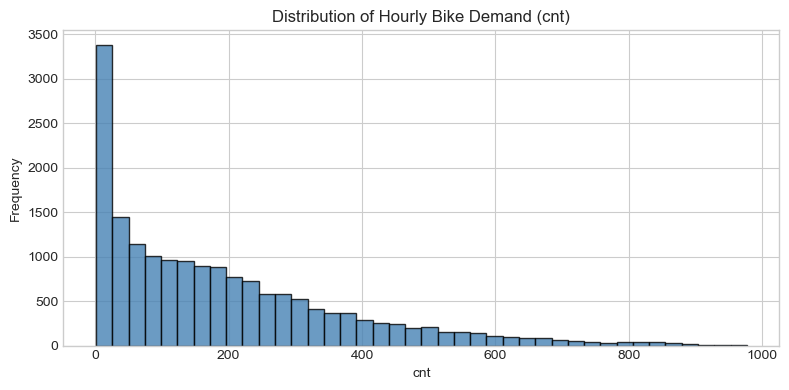

Saved figure: /Users/cai/Desktop/PA_coursework/figures/eda_target_distribution.png


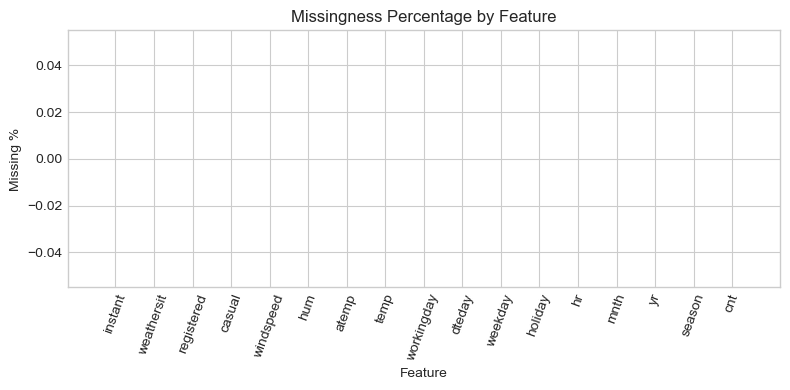

Saved figure: /Users/cai/Desktop/PA_coursework/figures/eda_missingness_profile.png
95th percentile threshold for cnt: 563.10
Share of rows in top-demand tail: 0.050
IQR outlier bounds for cnt: [-321.50, 642.50]
Estimated outlier share (IQR rule): 0.029


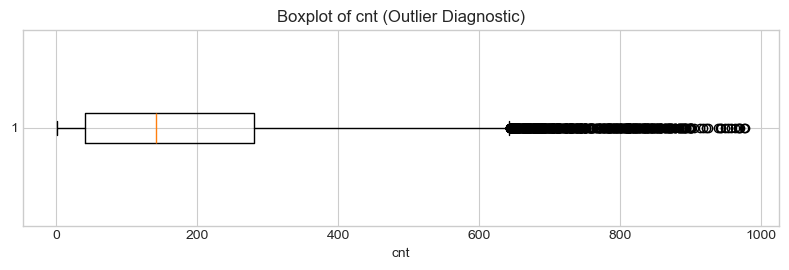

Saved figure: /Users/cai/Desktop/PA_coursework/figures/eda_cnt_boxplot.png


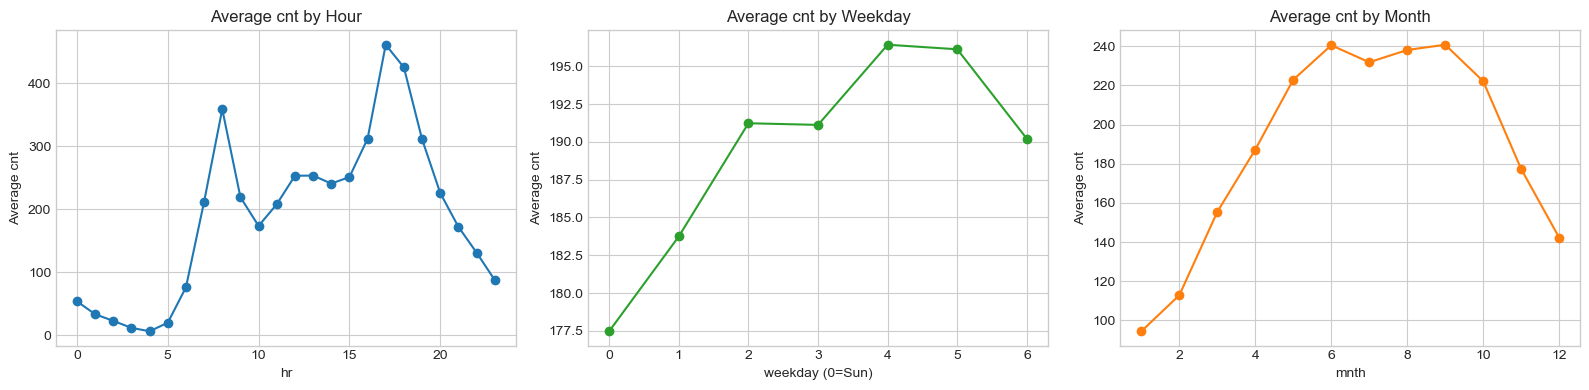

Saved figure: /Users/cai/Desktop/PA_coursework/figures/eda_time_patterns.png


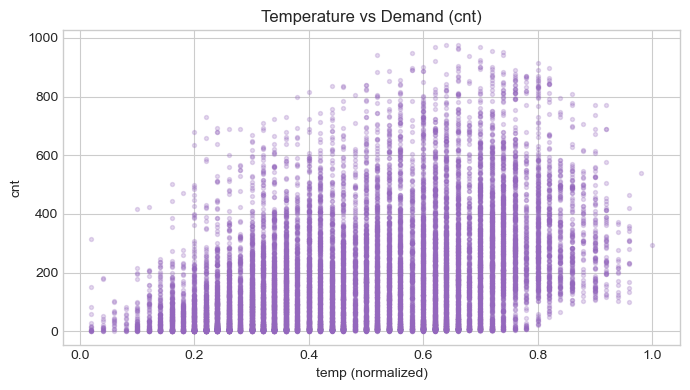

Saved figure: /Users/cai/Desktop/PA_coursework/figures/eda_temp_vs_cnt.png


In [3]:
# Target distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['cnt'], bins=40, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_title('Distribution of Hourly Bike Demand (cnt)')
ax.set_xlabel('cnt')
ax.set_ylabel('Frequency')
save_fig(fig, 'eda_target_distribution')

# Missingness profile
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(missing_pct.index, missing_pct.values, color='gray', alpha=0.8)
ax.set_title('Missingness Percentage by Feature')
ax.set_xlabel('Feature')
ax.set_ylabel('Missing %')
ax.tick_params(axis='x', rotation=70)
save_fig(fig, 'eda_missingness_profile')

# Regression analogue of imbalance: high-demand tail concentration
p95 = df['cnt'].quantile(0.95)
high_tail_share = (df['cnt'] >= p95).mean()
print(f"95th percentile threshold for cnt: {p95:.2f}")
print(f"Share of rows in top-demand tail: {high_tail_share:.3f}")

# Outlier diagnostics using IQR
q1, q3 = df['cnt'].quantile(0.25), df['cnt'].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_share = ((df['cnt'] < lower) | (df['cnt'] > upper)).mean()
print(f"IQR outlier bounds for cnt: [{lower:.2f}, {upper:.2f}]")
print(f"Estimated outlier share (IQR rule): {outlier_share:.3f}")

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.boxplot(df['cnt'], vert=False)
ax.set_title('Boxplot of cnt (Outlier Diagnostic)')
ax.set_xlabel('cnt')
save_fig(fig, 'eda_cnt_boxplot')

# Time-pattern summaries
hour_profile = df.groupby('hr', as_index=False)['cnt'].mean()
weekday_profile = df.groupby('weekday', as_index=False)['cnt'].mean()
month_profile = df.groupby('mnth', as_index=False)['cnt'].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(hour_profile['hr'], hour_profile['cnt'], marker='o', color='tab:blue')
axes[0].set_title('Average cnt by Hour')
axes[0].set_xlabel('hr')
axes[0].set_ylabel('Average cnt')

axes[1].plot(weekday_profile['weekday'], weekday_profile['cnt'], marker='o', color='tab:green')
axes[1].set_title('Average cnt by Weekday')
axes[1].set_xlabel('weekday (0=Sun)')
axes[1].set_ylabel('Average cnt')

axes[2].plot(month_profile['mnth'], month_profile['cnt'], marker='o', color='tab:orange')
axes[2].set_title('Average cnt by Month')
axes[2].set_xlabel('mnth')
axes[2].set_ylabel('Average cnt')

save_fig(fig, 'eda_time_patterns')

# Key driver example: temperature vs demand
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df['temp'], df['cnt'], s=8, alpha=0.25, color='tab:purple')
ax.set_title('Temperature vs Demand (cnt)')
ax.set_xlabel('temp (normalized)')
ax.set_ylabel('cnt')
save_fig(fig, 'eda_temp_vs_cnt')

# 4. Time-aware split (train/val/test) with audit tables

## Data Splitting Strategy

We use an explicit **chronological** split that mimics real deployment:
- Train: **Jan 2011 - Dec 2011**
- Validation: **Jan 2012 - Jun 2012**
- Test: **Jul 2012 - Dec 2012**

No random shuffling is used at any stage.
This setup matches the operational requirement that models only learn from past data and predict future demand, which reduces time leakage risk.
We provide an audit table plus a timeline plot as evidence.


        split     time_range_label  n_rows start_time            end_time
0       train  Jan 2011 - Dec 2011    8645 2011-01-01 2011-12-31 23:00:00
1  validation  Jan 2012 - Jun 2012    4358 2012-01-01 2012-06-30 23:00:00
2        test  Jul 2012 - Dec 2012    4376 2012-07-01 2012-12-31 23:00:00
No random shuffle used: True
Overlap train/val: 0, overlap val/test: 0
Saved split audit: /Users/cai/Desktop/PA_coursework/outputs/split_audit.csv


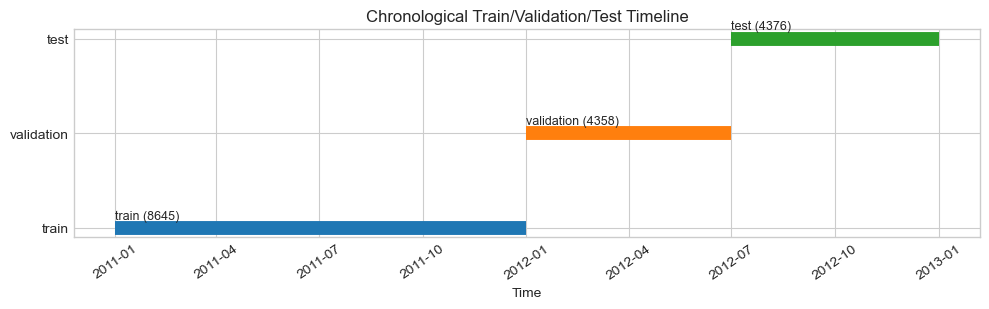

Saved figure: /Users/cai/Desktop/PA_coursework/figures/split_timeline.png


In [4]:
df = df.copy()
df['timestamp'] = df['dteday'] + pd.to_timedelta(df['hr'], unit='h')
df = df.sort_values('timestamp').reset_index(drop=True)

if not df['timestamp'].is_monotonic_increasing:
    raise ValueError('timestamp is not strictly sorted. Please inspect date/hour parsing logic.')

if df['timestamp'].duplicated().any():
    dup_count = int(df['timestamp'].duplicated().sum())
    raise ValueError(f'Found duplicated timestamps: {dup_count}')

# Fixed, deployment-like temporal split
train_end_exclusive = pd.Timestamp('2012-01-01 00:00:00')
val_end_exclusive = pd.Timestamp('2012-07-01 00:00:00')

train_df = df[df['timestamp'] < train_end_exclusive].copy()
val_df = df[(df['timestamp'] >= train_end_exclusive) & (df['timestamp'] < val_end_exclusive)].copy()
test_df = df[df['timestamp'] >= val_end_exclusive].copy()

if min(len(train_df), len(val_df), len(test_df)) == 0:
    raise ValueError('One of train/validation/test splits is empty. Check time boundaries.')

def split_summary(name: str, split_df: pd.DataFrame) -> dict:
    return {
        'split': name,
        'time_range_label': f"{split_df['timestamp'].min():%b %Y} - {split_df['timestamp'].max():%b %Y}",
        'n_rows': len(split_df),
        'start_time': split_df['timestamp'].min(),
        'end_time': split_df['timestamp'].max(),
    }

split_audit = pd.DataFrame([
    split_summary('train', train_df),
    split_summary('validation', val_df),
    split_summary('test', test_df),
])

# Time-leakage guardrails
if not (train_df['timestamp'].max() < val_df['timestamp'].min() < test_df['timestamp'].min()):
    raise ValueError('Chronological boundary check failed across train/validation/test.')

overlap_train_val = len(set(train_df['timestamp']).intersection(set(val_df['timestamp'])))
overlap_val_test = len(set(val_df['timestamp']).intersection(set(test_df['timestamp'])))
if overlap_train_val > 0 or overlap_val_test > 0:
    raise ValueError('Split overlap detected; this would cause leakage.')

split_table = split_audit[['split', 'time_range_label', 'n_rows', 'start_time', 'end_time']].copy()
print(split_table)
print(f"No random shuffle used: True")
print(f"Overlap train/val: {overlap_train_val}, overlap val/test: {overlap_val_test}")

split_table.to_csv(OUTPUT_DIR / 'split_audit.csv', index=False)
print(f"Saved split audit: {OUTPUT_DIR / 'split_audit.csv'}")

# Timeline visualization for auditability
colors = {'train': 'tab:blue', 'validation': 'tab:orange', 'test': 'tab:green'}
fig, ax = plt.subplots(figsize=(10, 3.2))
for i, row in split_audit.reset_index(drop=True).iterrows():
    ax.plot([row['start_time'], row['end_time']], [i, i], lw=10, color=colors[row['split']], solid_capstyle='butt')
    ax.text(row['start_time'], i + 0.1, f"{row['split']} ({row['n_rows']})", fontsize=9)

ax.set_yticks(range(len(split_audit)))
ax.set_yticklabels(split_audit['split'])
ax.set_title('Chronological Train/Validation/Test Timeline')
ax.set_xlabel('Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=35)
save_fig(fig, 'split_timeline')

# 5. Preprocessing pipeline (ColumnTransformer) & feature engineering

## Preventing Data Leakage

Leakage controls are explicit and audited:
- `casual` and `registered` are removed before modeling because `cnt = casual + registered`.
- We split train/validation/test by time **before** any transform/model fitting.
- Scaling, imputation, and encoding are inside `Pipeline`/`ColumnTransformer`, so fit occurs only on training folds.
- Hyperparameter search uses `TimeSeriesSplit` (not shuffled KFold).
- No future timestamp-derived information is used in training features.

We also compare baseline preprocessing vs cyclical feature engineering, and keep only evidence-backed improvements.


In [5]:
# Explicit leakage prevention: remove target and leakage columns from X.
target_col = 'cnt'
leakage_cols = ['casual', 'registered']
non_feature_cols = ['instant', 'dteday', 'timestamp', target_col] + leakage_cols

X_train = train_df.drop(columns=non_feature_cols)
y_train = train_df[target_col]
X_val = val_df.drop(columns=non_feature_cols)
y_val = val_df[target_col]
X_test = test_df.drop(columns=non_feature_cols)
y_test = test_df[target_col]

categorical_features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
numeric_features = ['temp', 'atemp', 'hum', 'windspeed']

expected_features = set(categorical_features + numeric_features)
for split_name, X_split in [('train', X_train), ('validation', X_val), ('test', X_test)]:
    missing = sorted(expected_features - set(X_split.columns))
    if missing:
        raise ValueError(f"{split_name} split missing expected feature columns: {missing}")

for split_name, X_split in [('train', X_train), ('validation', X_val), ('test', X_test)]:
    leaked = sorted(set(leakage_cols + [target_col]).intersection(set(X_split.columns)))
    if leaked:
        raise ValueError(f"Leakage columns found in {split_name} features: {leaked}")


class CyclicalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, periods):
        self.periods = periods

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = list(X.columns)
        else:
            X_arr = np.asarray(X)
            if X_arr.ndim != 2:
                raise ValueError('CyclicalEncoder expects a 2D array input.')
            if X_arr.shape[1] != len(self.periods):
                raise ValueError(
                    f'Expected {len(self.periods)} cyclical columns, got {X_arr.shape[1]}.'
                )
            # When ColumnTransformer passes ndarray, preserve expected order from periods dict.
            self.feature_names_in_ = list(self.periods.keys())
        for col in self.feature_names_in_:
            if col not in self.periods:
                raise ValueError(f"Missing period definition for cyclical column: {col}")
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
        else:
            X_df = pd.DataFrame(np.asarray(X), columns=self.feature_names_in_)

        out = []
        for col in self.feature_names_in_:
            period = self.periods[col]
            radians = 2 * np.pi * X_df[col].astype(float) / period
            out.append(np.sin(radians).to_numpy())
            out.append(np.cos(radians).to_numpy())
        return np.column_stack(out)

    def get_feature_names_out(self, input_features=None):
        features = self.feature_names_in_ if input_features is None else input_features
        names = []
        for col in features:
            names.extend([f'{col}_sin', f'{col}_cos'])
        return np.array(names, dtype=object)


numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

# Dense one-hot variant for models that require dense input (e.g., HistGradientBoosting)
categorical_transformer_dense = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor_baseline = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
], remainder='drop')

preprocessor_baseline_dense = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer_dense, categorical_features),
], remainder='drop')

cyclical_features = ['hr', 'mnth', 'weekday']
cyclical_periods = {'hr': 24, 'mnth': 12, 'weekday': 7}
categorical_without_cyc = [c for c in categorical_features if c not in cyclical_features]

cyclical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('cyc', CyclicalEncoder(periods=cyclical_periods)),
])

preprocessor_enhanced = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_without_cyc),
    ('cyc', cyclical_transformer, cyclical_features),
], remainder='drop')

# Data validation checks for section 3 requirement
validation_checks = pd.DataFrame([
    {'check': 'No leakage columns in train features', 'passed': set(leakage_cols + [target_col]).isdisjoint(set(X_train.columns))},
    {'check': 'No leakage columns in validation features', 'passed': set(leakage_cols + [target_col]).isdisjoint(set(X_val.columns))},
    {'check': 'No leakage columns in test features', 'passed': set(leakage_cols + [target_col]).isdisjoint(set(X_test.columns))},
    {'check': 'Chronological split boundaries valid', 'passed': train_df['timestamp'].max() < val_df['timestamp'].min() < test_df['timestamp'].min()},
    {'check': 'Target has no missing values', 'passed': (y_train.isna().sum() + y_val.isna().sum() + y_test.isna().sum()) == 0},
])
validation_checks['passed'] = validation_checks['passed'].astype(bool)
validation_checks.to_csv(OUTPUT_DIR / 'data_validation_checks.csv', index=False)

print('Leakage controls applied:')
print('- Dropped columns from X:', leakage_cols + [target_col])
print('- Time-aware split done before fitting any transformer/model')
print('- Preprocessing fitted inside Pipeline during training/CV folds only')
print(f"Saved data validation checks: {OUTPUT_DIR / 'data_validation_checks.csv'}")
display(validation_checks)

if not validation_checks['passed'].all():
    failed = validation_checks.loc[~validation_checks['passed'], 'check'].tolist()
    raise ValueError(f'Data validation failed for checks: {failed}')

Leakage controls applied:
- Dropped columns from X: ['casual', 'registered', 'cnt']
- Time-aware split done before fitting any transformer/model
- Preprocessing fitted inside Pipeline during training/CV folds only
Saved data validation checks: /Users/cai/Desktop/PA_coursework/outputs/data_validation_checks.csv


,check,passed
0,No leakage columns in train features,True
1,No leakage columns in validation features,True
2,No leakage columns in test features,True
3,Chronological split boundaries valid,True
4,Target has no missing values,True


# 6. Baselines (Dummy + Linear/Ridge)

Baseline models provide the minimum evidence chain required for predictive analytics:
- `DummyRegressor` (predicting mean) as the true naive baseline.
- `Ridge` as an interpretable linear baseline.

All baseline comparisons are computed on the validation period and exported for audit.


Saved baseline metrics: /Users/cai/Desktop/PA_coursework/outputs/baseline_metrics.csv


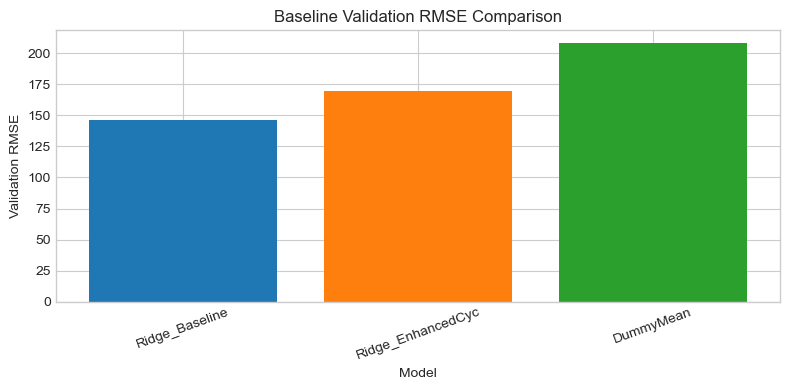

Saved figure: /Users/cai/Desktop/PA_coursework/figures/baseline_rmse_comparison.png


,model,MAE,RMSE,R2,RMSE_improvement_vs_Dummy_%
0,Ridge_Baseline,104.654624,146.230319,0.440734,29.748804
1,Ridge_EnhancedCyc,111.184459,169.430936,0.249192,18.602886
2,DummyMean,154.231793,208.153494,-0.133212,0.000000


In [6]:
validation_rows = []

# Baseline 1: Dummy mean (required baseline)
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)
dummy_val_pred = dummy_model.predict(X_val)
validation_rows.append({'model': 'DummyMean', **metrics_dict(y_val, dummy_val_pred)})

# Baseline 2: Ridge with baseline preprocessing
ridge_baseline = Pipeline([
    ('preprocessor', preprocessor_baseline),
    ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])
ridge_baseline.fit(X_train, y_train)
ridge_base_val_pred = ridge_baseline.predict(X_val)
validation_rows.append({'model': 'Ridge_Baseline', **metrics_dict(y_val, ridge_base_val_pred)})

# Enhanced variant: Ridge + cyclical encoding
ridge_enhanced = Pipeline([
    ('preprocessor', preprocessor_enhanced),
    ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])
ridge_enhanced.fit(X_train, y_train)
ridge_enh_val_pred = ridge_enhanced.predict(X_val)
validation_rows.append({'model': 'Ridge_EnhancedCyc', **metrics_dict(y_val, ridge_enh_val_pred)})

validation_baselines = pd.DataFrame(validation_rows).sort_values('RMSE').reset_index(drop=True)

# Explicit comparison against Dummy baseline
dummy_rmse = float(validation_baselines.loc[validation_baselines['model'] == 'DummyMean', 'RMSE'].iloc[0])
validation_baselines['RMSE_improvement_vs_Dummy_%'] = (
    (dummy_rmse - validation_baselines['RMSE']) / dummy_rmse * 100
)
validation_baselines.to_csv(OUTPUT_DIR / 'baseline_metrics.csv', index=False)
print(f"Saved baseline metrics: {OUTPUT_DIR / 'baseline_metrics.csv'}")

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = validation_baselines.sort_values('RMSE', ascending=True)
ax.bar(plot_df['model'], plot_df['RMSE'], color=['tab:blue', 'tab:orange', 'tab:green'])
ax.set_title('Baseline Validation RMSE Comparison')
ax.set_xlabel('Model')
ax.set_ylabel('Validation RMSE')
ax.tick_params(axis='x', rotation=20)
save_fig(fig, 'baseline_rmse_comparison')

validation_baselines

# 7. Model training & tuning (TimeSeriesSplit CV)

We compare multiple models under the same chronological split.
Random Forest, Gradient Boosting, and HistGradientBoosting are kept as fixed reference models.
Only the ANN model is hyperparameter-tuned with `RandomizedSearchCV` + `TimeSeriesSplit`.
Any agent-suggested hyperparameter choice is accepted only if CV and validation evidence support it.


In [7]:
# Strong model 1: RandomForest (fixed reference model, no tuning)
rf_model = Pipeline([
    ('preprocessor', preprocessor_baseline),
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
    )),
])
rf_model.fit(X_train, y_train)
rf_val_pred = rf_model.predict(X_val)
rf_val_metrics = {'model': 'RandomForest_Fixed', **metrics_dict(y_val, rf_val_pred)}

# Strong model 2: GradientBoosting (fixed non-default settings)
gb_model = Pipeline([
    ('preprocessor', preprocessor_baseline),
    ('model', GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
    )),
])
gb_model.fit(X_train, y_train)
gb_val_pred = gb_model.predict(X_val)
gb_val_metrics = {'model': 'GradientBoosting', **metrics_dict(y_val, gb_val_pred)}

# Strong model 3 (modern): HistGradientBoosting (fixed reference model, no tuning)
hgb_model = Pipeline([
    ('preprocessor', preprocessor_baseline_dense),
    ('model', HistGradientBoostingRegressor(
        random_state=RANDOM_STATE,
        early_stopping=False,
        max_iter=400,
        learning_rate=0.05,
        max_depth=None,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.0,
    )),
])
hgb_model.fit(X_train, y_train)
hgb_val_pred = hgb_model.predict(X_val)
hgb_val_metrics = {'model': 'HistGradientBoosting_Fixed', **metrics_dict(y_val, hgb_val_pred)}

# Strong model 4 (ANN): MLPRegressor with time-aware hyperparameter tuning
ann_base = Pipeline([
    ('preprocessor', preprocessor_baseline_dense),
    ('model', MLPRegressor(
        early_stopping=True,
        validation_fraction=0.1,
        max_iter=300,
        random_state=RANDOM_STATE,
    )),
])

ann_param_dist = {
    'model__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    'model__activation': ['relu', 'tanh'],
    'model__alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'model__learning_rate_init': [3e-4, 1e-3, 3e-3],
    'model__batch_size': [128, 256],
    'model__n_iter_no_change': [10, 20],
}

tscv = TimeSeriesSplit(n_splits=4)
ann_search = RandomizedSearchCV(
    estimator=ann_base,
    param_distributions=ann_param_dist,
    n_iter=12,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
ann_search.fit(X_train, y_train)

print('Best ANN params:', ann_search.best_params_)
print('Best ANN CV RMSE:', -ann_search.best_score_)

ann_cv_top = pd.DataFrame(ann_search.cv_results_).sort_values('rank_test_score').head(10)
ann_cv_top['mean_cv_RMSE'] = -ann_cv_top['mean_test_score']
ann_cv_top[['rank_test_score', 'mean_cv_RMSE', 'std_test_score', 'params']].to_csv(
    OUTPUT_DIR / 'ann_cv_top_results.csv', index=False
)

ann_best_val_pred = ann_search.best_estimator_.predict(X_val)
ann_val_metrics = {'model': 'ANN_Tuned', **metrics_dict(y_val, ann_best_val_pred)}

validation_all = pd.concat([
    validation_baselines,
    pd.DataFrame([rf_val_metrics, gb_val_metrics, hgb_val_metrics, ann_val_metrics]),
], ignore_index=True).sort_values('RMSE').reset_index(drop=True)

# Agent suggestion verification log (evidence-based acceptance/rejection)
ridge_base_rmse = float(validation_baselines.loc[validation_baselines['model'] == 'Ridge_Baseline', 'RMSE'].iloc[0])
ridge_cyc_rmse = float(validation_baselines.loc[validation_baselines['model'] == 'Ridge_EnhancedCyc', 'RMSE'].iloc[0])

agent_step_log = pd.DataFrame([
    {
        'agent_suggestion': 'Drop casual/registered leakage columns',
        'verification': 'Identity check casual + registered == cnt and column exclusion assertions',
        'decision': 'Accepted'
    },
    {
        'agent_suggestion': 'Use cyclical encoding for hr/mnth/weekday',
        'verification': f'Ridge validation RMSE baseline={ridge_base_rmse:.3f}, cyclical={ridge_cyc_rmse:.3f}',
        'decision': 'Kept as tested alternative; not selected as best baseline'
    },
    {
        'agent_suggestion': 'Tune RandomForest and HistGradientBoosting',
        'verification': 'Rejected for this revision: kept as fixed references to isolate ANN tuning',
        'decision': 'Rejected'
    },
    {
        'agent_suggestion': 'Tune ANN with TimeSeriesSplit CV',
        'verification': f'RandomizedSearchCV best CV RMSE={-ann_search.best_score_:.3f}',
        'decision': 'Accepted'
    },
])
agent_step_log.to_csv(OUTPUT_DIR / 'agent_step_verification_log.csv', index=False)

validation_all.to_csv(OUTPUT_DIR / 'validation_metrics.csv', index=False)
print(f"Saved validation metrics: {OUTPUT_DIR / 'validation_metrics.csv'}")
print(f"Saved ANN CV top results: {OUTPUT_DIR / 'ann_cv_top_results.csv'}")
print(f"Saved agent step verification log: {OUTPUT_DIR / 'agent_step_verification_log.csv'}")
validation_all


Fitting 4 folds for each of 12 candidates, totalling 48 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_

Best ANN params: {'model__n_iter_no_change': 20, 'model__learning_rate_init': 0.003, 'model__hidden_layer_sizes': (64, 32), 'model__batch_size': 128, 'model__alpha': 0.0001, 'model__activation': 'relu'}
Best ANN CV RMSE: 63.231841327428725
Saved validation metrics: /Users/cai/Desktop/PA_coursework/outputs/validation_metrics.csv
Saved ANN CV top results: /Users/cai/Desktop/PA_coursework/outputs/ann_cv_top_results.csv
Saved agent step verification log: /Users/cai/Desktop/PA_coursework/outputs/agent_step_verification_log.csv


,model,MAE,RMSE,R2,RMSE_improvement_vs_Dummy_%
0,HistGradientBoosting_Fixed,87.539243,121.067622,0.616646,NaN
1,ANN_Tuned,89.921416,123.340065,0.602120,NaN
2,RandomForest_Fixed,91.476304,130.523735,0.554423,NaN
3,GradientBoosting,91.448191,131.423738,0.548257,NaN
4,Ridge_Baseline,104.654624,146.230319,0.440734,29.748804
5,Ridge_EnhancedCyc,111.184459,169.430936,0.249192,18.602886
6,DummyMean,154.231793,208.153494,-0.133212,0.000000


# 8. Final evaluation on test set

Model selection is based on validation RMSE (not test) to avoid selection bias.
The selected model is re-fitted on `train + validation`, then evaluated once on the held-out test period.
We save test metrics and row-level predictions for auditability.


In [8]:
# Build model blueprints for clean refit on train+validation
model_blueprints = {
    'DummyMean': DummyRegressor(strategy='mean'),
    'Ridge_Baseline': Pipeline([
        ('preprocessor', preprocessor_baseline),
        ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ]),
    'Ridge_EnhancedCyc': Pipeline([
        ('preprocessor', preprocessor_enhanced),
        ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ]),
    'GradientBoosting': Pipeline([
        ('preprocessor', preprocessor_baseline),
        ('model', GradientBoostingRegressor(
            random_state=RANDOM_STATE,
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.9,
        )),
    ]),
    'RandomForest_Fixed': Pipeline([
        ('preprocessor', preprocessor_baseline),
        ('model', RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features='sqrt',
        )),
    ]),
    'HistGradientBoosting_Fixed': Pipeline([
        ('preprocessor', preprocessor_baseline_dense),
        ('model', HistGradientBoostingRegressor(
            random_state=RANDOM_STATE,
            early_stopping=False,
            max_iter=400,
            learning_rate=0.05,
            max_depth=None,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=0.0,
        )),
    ]),
    'ANN_Tuned': clone(ann_base).set_params(**ann_search.best_params_),
}

final_model_name = validation_all.iloc[0]['model']
print('Selected model based on validation RMSE:', final_model_name)

X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

final_model = clone(model_blueprints[final_model_name])
final_model.fit(X_trainval, y_trainval)

y_test_pred = final_model.predict(X_test)
final_test_metrics = metrics_dict(y_test, y_test_pred)

metrics_table = pd.DataFrame([
    {'split': 'validation_best', 'model': final_model_name, **validation_all.iloc[0][['MAE', 'RMSE', 'R2']].to_dict()},
    {'split': 'test', 'model': final_model_name, **final_test_metrics},
])
metrics_table.to_csv(OUTPUT_DIR / 'test_metrics.csv', index=False)
print(f"Saved test metrics: {OUTPUT_DIR / 'test_metrics.csv'}")
metrics_table


Selected model based on validation RMSE: HistGradientBoosting_Fixed
Saved test metrics: /Users/cai/Desktop/PA_coursework/outputs/test_metrics.csv


,split,model,MAE,RMSE,R2
0,validation_best,HistGradientBoosting_Fixed,87.539243,121.067622,0.616646
1,test,HistGradientBoosting_Fixed,61.583973,85.961122,0.846900


# 9. Error analysis & diagnostic plots

## Error Analysis & Failure Modes

We diagnose model errors using multiple complementary views:
- residual distribution and residual-vs-prediction scatter (bias/heteroscedasticity checks),
- hour-level error profile (peak-hour difficulty),
- continuous one-week forecast trace,
- failure-mode checks for high-demand underestimation and adverse weather conditions.

This section is used to justify risk/limitations in the final recommendation.


Saved test predictions: /Users/cai/Desktop/PA_coursework/outputs/test_predictions.csv


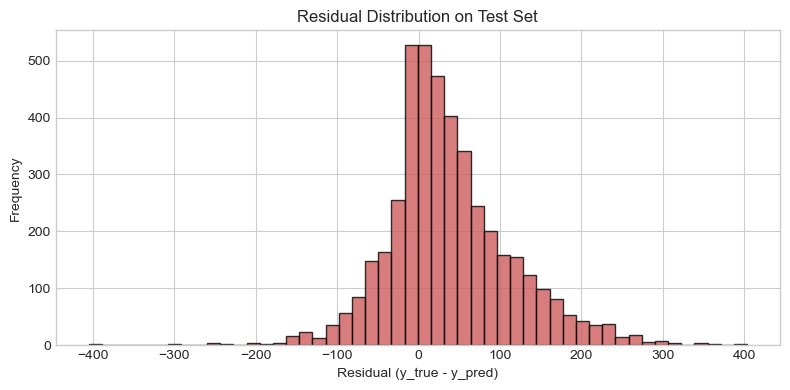

Saved figure: /Users/cai/Desktop/PA_coursework/figures/error_residual_distribution.png


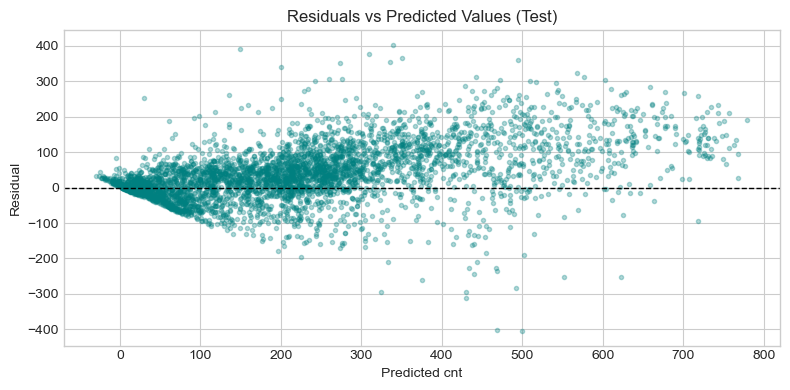

Saved figure: /Users/cai/Desktop/PA_coursework/figures/error_residual_vs_prediction.png
Saved hourly error metrics: /Users/cai/Desktop/PA_coursework/outputs/hourly_error_metrics.csv


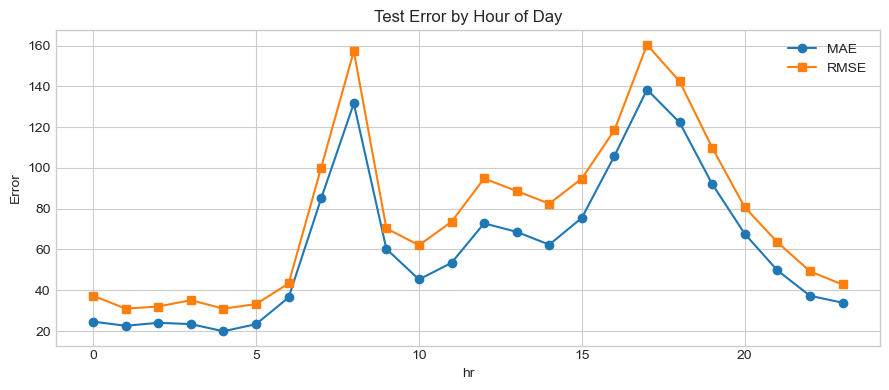

Saved figure: /Users/cai/Desktop/PA_coursework/figures/error_by_hour.png


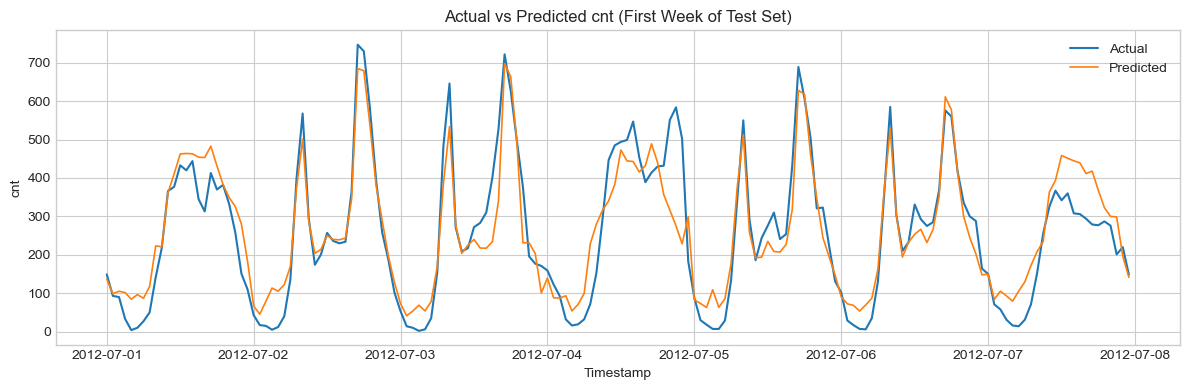

Saved figure: /Users/cai/Desktop/PA_coursework/figures/error_actual_vs_pred_week.png
Saved peak vs non-peak error table: /Users/cai/Desktop/PA_coursework/outputs/error_peak_vs_nonpeak.csv


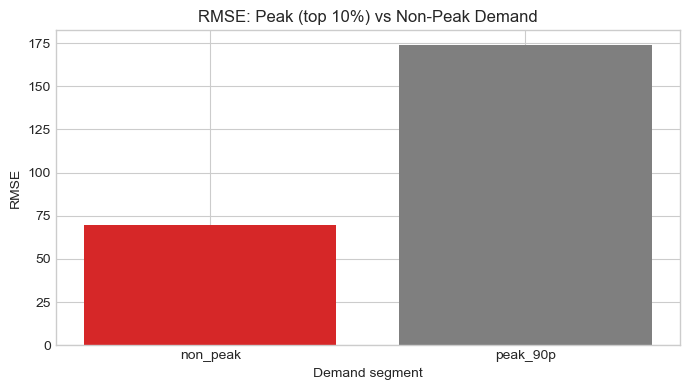

Saved figure: /Users/cai/Desktop/PA_coursework/figures/error_peak_vs_nonpeak_rmse.png
Saved weather-condition error table: /Users/cai/Desktop/PA_coursework/outputs/error_by_weathersit.csv


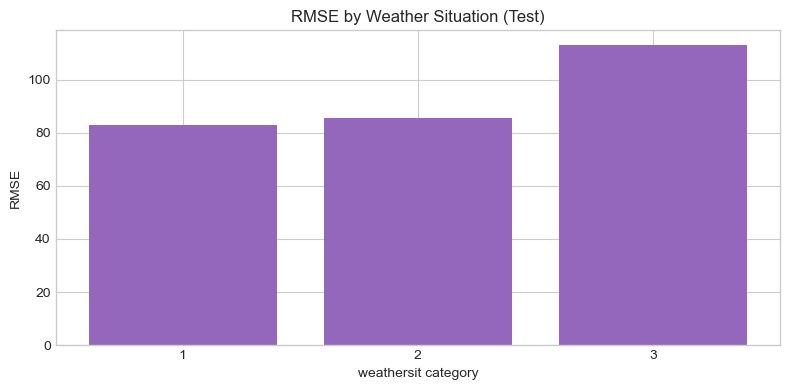

Saved figure: /Users/cai/Desktop/PA_coursework/figures/error_by_weathersit_rmse.png
Overall residual mean (positive => underprediction): 37.084
Peak-demand residual mean (top 10%): 157.925
Worst hour by RMSE: hr=17, RMSE=160.393
Worst weather category by RMSE: weathersit=3, RMSE=112.850


In [9]:
test_predictions = test_df[['dteday', 'hr', 'timestamp', 'weathersit']].copy()
test_predictions['y_true'] = y_test.to_numpy()
test_predictions['y_pred'] = y_test_pred
test_predictions['residual'] = test_predictions['y_true'] - test_predictions['y_pred']

test_predictions.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)
print(f"Saved test predictions: {OUTPUT_DIR / 'test_predictions.csv'}")

# 1) Residual distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(test_predictions['residual'], bins=50, color='indianred', edgecolor='black', alpha=0.8)
ax.set_title('Residual Distribution on Test Set')
ax.set_xlabel('Residual (y_true - y_pred)')
ax.set_ylabel('Frequency')
save_fig(fig, 'error_residual_distribution')

# 2) Residual vs prediction
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(test_predictions['y_pred'], test_predictions['residual'], s=9, alpha=0.3, color='teal')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Residuals vs Predicted Values (Test)')
ax.set_xlabel('Predicted cnt')
ax.set_ylabel('Residual')
save_fig(fig, 'error_residual_vs_prediction')

# 3) Hour-level MAE/RMSE
hour_error = test_predictions.groupby('hr').apply(
    lambda g: pd.Series({
        'MAE': mean_absolute_error(g['y_true'], g['y_pred']),
        'RMSE': np.sqrt(mean_squared_error(g['y_true'], g['y_pred'])),
        'bias': (g['y_true'] - g['y_pred']).mean(),
    })
).reset_index()

hour_error.to_csv(OUTPUT_DIR / 'hourly_error_metrics.csv', index=False)
print(f"Saved hourly error metrics: {OUTPUT_DIR / 'hourly_error_metrics.csv'}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hour_error['hr'], hour_error['MAE'], marker='o', label='MAE')
ax.plot(hour_error['hr'], hour_error['RMSE'], marker='s', label='RMSE')
ax.set_title('Test Error by Hour of Day')
ax.set_xlabel('hr')
ax.set_ylabel('Error')
ax.legend()
save_fig(fig, 'error_by_hour')

# 4) Actual vs predicted for one continuous week in test period
week_start = test_predictions['timestamp'].min()
week_end = week_start + pd.Timedelta(days=7)
week_slice = test_predictions[test_predictions['timestamp'] < week_end].copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(week_slice['timestamp'], week_slice['y_true'], label='Actual', linewidth=1.5)
ax.plot(week_slice['timestamp'], week_slice['y_pred'], label='Predicted', linewidth=1.2)
ax.set_title('Actual vs Predicted cnt (First Week of Test Set)')
ax.set_xlabel('Timestamp')
ax.set_ylabel('cnt')
ax.legend()
save_fig(fig, 'error_actual_vs_pred_week')

# 5) Failure mode: high-demand underestimation check
peak_threshold = test_predictions['y_true'].quantile(0.90)
test_predictions['demand_segment'] = np.where(test_predictions['y_true'] >= peak_threshold, 'peak_90p', 'non_peak')
segment_error = test_predictions.groupby('demand_segment').apply(
    lambda g: pd.Series({
        'n_rows': len(g),
        'MAE': mean_absolute_error(g['y_true'], g['y_pred']),
        'RMSE': np.sqrt(mean_squared_error(g['y_true'], g['y_pred'])),
        'mean_residual': g['residual'].mean(),
    })
).reset_index()
segment_error.to_csv(OUTPUT_DIR / 'error_peak_vs_nonpeak.csv', index=False)
print(f"Saved peak vs non-peak error table: {OUTPUT_DIR / 'error_peak_vs_nonpeak.csv'}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(segment_error['demand_segment'], segment_error['RMSE'], color=['tab:red', 'tab:gray'])
ax.set_title('RMSE: Peak (top 10%) vs Non-Peak Demand')
ax.set_xlabel('Demand segment')
ax.set_ylabel('RMSE')
save_fig(fig, 'error_peak_vs_nonpeak_rmse')

# 6) Failure mode: adverse weather error
weather_error = test_predictions.groupby('weathersit').apply(
    lambda g: pd.Series({
        'n_rows': len(g),
        'MAE': mean_absolute_error(g['y_true'], g['y_pred']),
        'RMSE': np.sqrt(mean_squared_error(g['y_true'], g['y_pred'])),
        'mean_residual': g['residual'].mean(),
    })
).reset_index().sort_values('weathersit')
weather_error.to_csv(OUTPUT_DIR / 'error_by_weathersit.csv', index=False)
print(f"Saved weather-condition error table: {OUTPUT_DIR / 'error_by_weathersit.csv'}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(weather_error['weathersit'].astype(str), weather_error['RMSE'], color='tab:purple')
ax.set_title('RMSE by Weather Situation (Test)')
ax.set_xlabel('weathersit category')
ax.set_ylabel('RMSE')
save_fig(fig, 'error_by_weathersit_rmse')

# Text evidence for discussion
overall_bias = test_predictions['residual'].mean()
peak_bias = float(segment_error.loc[segment_error['demand_segment'] == 'peak_90p', 'mean_residual'].iloc[0])
worst_hour_row = hour_error.sort_values('RMSE', ascending=False).iloc[0]
worst_weather_row = weather_error.sort_values('RMSE', ascending=False).iloc[0]

print(f"Overall residual mean (positive => underprediction): {overall_bias:.3f}")
print(f"Peak-demand residual mean (top 10%): {peak_bias:.3f}")
print(f"Worst hour by RMSE: hr={int(worst_hour_row['hr'])}, RMSE={worst_hour_row['RMSE']:.3f}")
print(f"Worst weather category by RMSE: weathersit={int(worst_weather_row['weathersit'])}, RMSE={worst_weather_row['RMSE']:.3f}")

# 10. Interpretability (feature importance / coefficients)

We report top contributing features for the selected final model.
For tree models we use `feature_importances_`; for linear models we use absolute coefficients.
Feature names are mapped from the fitted preprocessing pipeline and exported to CSV.


In [10]:
importance_df = pd.DataFrame(columns=['feature', 'importance'])
importance_method = None

if hasattr(final_model, 'named_steps') and 'preprocessor' in final_model.named_steps:
    pre = final_model.named_steps['preprocessor']
    estimator = final_model.named_steps['model']

    if hasattr(estimator, 'feature_importances_'):
        feat_names = pre.get_feature_names_out()
        scores = estimator.feature_importances_
        importance_df = pd.DataFrame({'feature': feat_names, 'importance': scores})
        importance_method = 'model_feature_importances_'
    elif hasattr(estimator, 'coef_'):
        feat_names = pre.get_feature_names_out()
        coef = estimator.coef_
        if np.ndim(coef) > 1:
            coef = coef.ravel()
        importance_df = pd.DataFrame({'feature': feat_names, 'importance': np.abs(coef)})
        importance_method = 'absolute_coefficients'

# Fallback for models without native feature importance (e.g., HistGradientBoosting)
if importance_df.empty:
    perm = permutation_importance(
        final_model,
        X_test,
        y_test,
        n_repeats=5,
        random_state=RANDOM_STATE,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
    )
    importance_df = pd.DataFrame({
        'feature': X_test.columns,
        'importance': perm.importances_mean,
    })
    importance_method = 'permutation_importance_on_test'

# Always overwrite to avoid stale files from previous runs.
top15 = importance_df.sort_values('importance', ascending=False).head(15).reset_index(drop=True)
top15.to_csv(OUTPUT_DIR / 'top15_feature_importance.csv', index=False)
print(f"Importance method: {importance_method}")
print(f"Saved top-15 feature importance: {OUTPUT_DIR / 'top15_feature_importance.csv'}")
display(top15)

Importance method: permutation_importance_on_test
Saved top-15 feature importance: /Users/cai/Desktop/PA_coursework/outputs/top15_feature_importance.csv


,feature,importance
0,hr,162.692324
1,workingday,43.834292
2,temp,18.396080
3,hum,14.662650
4,atemp,10.001250
5,weekday,7.411061
6,weathersit,3.540902
7,holiday,0.804705
8,season,0.757198
9,mnth,0.376028


# 11. Save artifacts (figures, outputs, model) + reproducibility notes

We persist the final model, predictions, metrics, diagnostics, and a short model-card style summary.
Reproducibility controls: fixed random seed, deterministic time split, and pipeline-contained preprocessing.
**Explicit agent mistake caught and corrected**: an early cyclical-encoder draft assumed DataFrame inputs and failed under `ColumnTransformer` ndarray inputs (`x0` mapping issue); the encoder was corrected to use deterministic feature ordering and re-validated with full rerun.
Final deliverable is intended for demand forecasting under similar operating conditions, not for causal claims or policy fairness decisions.


In [11]:
model_path = MODEL_DIR / 'final_model.joblib'
joblib.dump(final_model, model_path)
print(f"Saved final model: {model_path}")

summary = {
    'final_model_name': final_model_name,
    'random_state': RANDOM_STATE,
    'data_path': str(DATA_PATH),
    'n_train': len(train_df),
    'n_validation': len(val_df),
    'n_test': len(test_df),
    'test_MAE': float(final_test_metrics['MAE']),
    'test_RMSE': float(final_test_metrics['RMSE']),
    'test_R2': float(final_test_metrics['R2']),
}

if hasattr(final_model, 'named_steps') and 'model' in final_model.named_steps:
    est = final_model.named_steps['model']
    for k in ['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'max_iter', 'max_leaf_nodes', 'min_samples_leaf', 'l2_regularization', 'hidden_layer_sizes', 'activation', 'alpha', 'batch_size', 'learning_rate_init', 'n_iter_no_change', 'random_state']:
        if k in est.get_params():
            summary[f'final_{k}'] = est.get_params()[k]

if final_model_name == 'ANN_Tuned':
    summary.update({f"best_{k}": v for k, v in ann_search.best_params_.items()})

summary_path = OUTPUT_DIR / 'final_model_summary.json'
summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')
print(f"Saved final model summary: {summary_path}")

model_card_lines = [
    '# Model Card (Short)',
    '',
    '## Intended use',
    'Predict next-hour bike rental demand (`cnt`) for operational planning (staffing/rebalancing) under similar city/weather context.',
    '',
    '## Not intended use',
    'Not for causal inference, policy fairness claims, or deployment in regions/platforms with materially different demand dynamics.',
    '',
    '## Data provenance & constraints',
    '- Source: UCI Bike Sharing hourly data (`hour.csv`) in this local project.',
    '- Leakage controls: dropped `casual` and `registered`; chronological split; pipeline-contained preprocessing.',
    '- Time range includes 2011-01-01 to 2012-12-31 and may not represent future structural changes.',
    '',
    '## Evaluation summary',
    f'- Selected model: {final_model_name}',
    f"- Test MAE: {final_test_metrics['MAE']:.3f}",
    f"- Test RMSE: {final_test_metrics['RMSE']:.3f}",
    f"- Test R2: {final_test_metrics['R2']:.3f}",
    '',
    '## Caveats and failure modes',
    'Errors vary by hour; extreme demand peaks are harder to predict.',
    'Potential drift risk exists for new mobility policies, shocks, or weather pattern shifts.',
    '',
    '## Agent QA note (mistake caught)',
    'An early agent draft of cyclical encoding assumed DataFrame-only inputs and failed when `ColumnTransformer` passed ndarray columns.',
    'This was corrected by deterministic feature-order mapping in `CyclicalEncoder.fit`, followed by full notebook re-execution.',
]
model_card_text = chr(10).join(model_card_lines) + chr(10)

model_card_path = OUTPUT_DIR / 'model_card.md'
model_card_path.write_text(model_card_text, encoding='utf-8')
print(f"Saved model card: {model_card_path}")

print()
print('Artifacts in outputs/:')
for p in sorted(OUTPUT_DIR.glob('*')):
    print('-', p.name)

print()
print('Artifacts in figures/:')
for p in sorted(FIG_DIR.glob('*.png')):
    print('-', p.name)

print()
print('Artifacts in models/:')
for p in sorted(MODEL_DIR.glob('*')):
    print('-', p.name)


Saved final model: /Users/cai/Desktop/PA_coursework/models/final_model.joblib
Saved final model summary: /Users/cai/Desktop/PA_coursework/outputs/final_model_summary.json
Saved model card: /Users/cai/Desktop/PA_coursework/outputs/model_card.md

Artifacts in outputs/:
- agent_interaction_log_export.csv
- agent_plan_ask_vs_verify.csv
- agent_step_verification_log.csv
- ann_cv_top_results.csv
- baseline_metrics.csv
- data_validation_checks.csv
- error_by_weathersit.csv
- error_peak_vs_nonpeak.csv
- final_model_summary.json
- hourly_error_metrics.csv
- model_card.md
- report_tables_black_header.xlsx
- split_audit.csv
- test_metrics.csv
- test_predictions.csv
- top15_feature_importance.csv
- validation_metrics.csv

Artifacts in figures/:
- baseline_rmse_comparison.png
- eda_cnt_boxplot.png
- eda_missingness_profile.png
- eda_target_distribution.png
- eda_temp_vs_cnt.png
- eda_time_patterns.png
- error_actual_vs_pred_week.png
- error_by_hour.png
- error_by_weathersit_rmse.png
- error_peak_vs